In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import ast
from pathlib import Path

In [ ]:
folder = Path('../data/processed')

movies_clean = pd.read_csv(folder / 'movies_clean.csv')
ratings_clean = pd.read_csv(folder / 'ratings_clean.csv')

In [ ]:
results_folder = Path('../results')

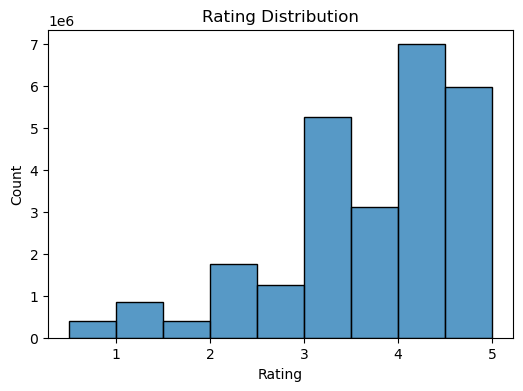

In [4]:
plt.figure(figsize=(6,4))
sns.histplot(ratings_clean["rating"], bins=9, kde=False)
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.savefig(f"{results_folder}\\rating_distribution.png", dpi=150)
plt.show()

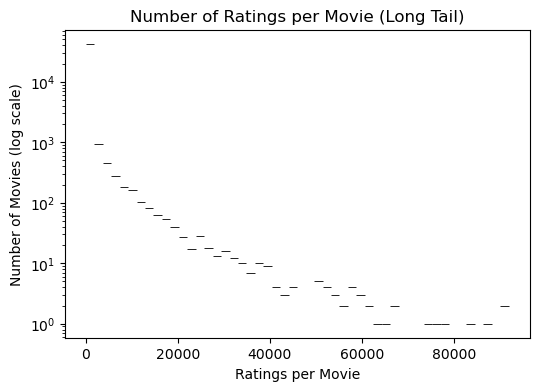

In [5]:
ratings_per_movie = ratings_clean.groupby('movieId')['rating'].count()

plt.figure(figsize=(6,4))
sns.histplot(ratings_per_movie, bins=50, log_scale=(False, True))  # y log scale
plt.title("Number of Ratings per Movie (Long Tail)")
plt.xlabel("Ratings per Movie")
plt.ylabel("Number of Movies (log scale)")
plt.savefig(f"{results_folder}\\longtail_movies.png", dpi=150)
plt.show()

On the left, you see most movies (tens of thousands) that have only a handful of ratings.
On the right, a tiny fraction of movies (blockbusters) have tens of thousands of ratings.
“The distribution of ratings per movie is highly skewed: most movies receive very few ratings, while a small set of popular titles dominate the dataset.”

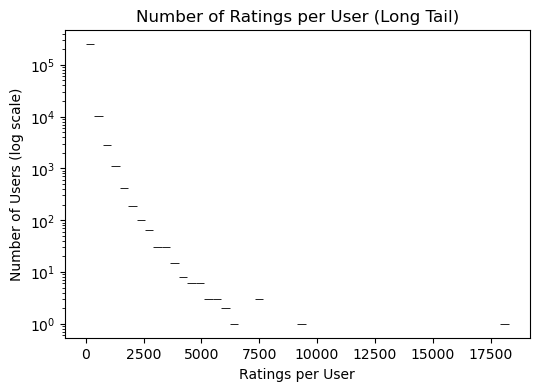

In [6]:
ratings_per_user = ratings_clean.groupby('userId')['rating'].count()

plt.figure(figsize=(6,4))
sns.histplot(ratings_per_user, bins=50, log_scale=(False, True))
plt.title("Number of Ratings per User (Long Tail)")
plt.xlabel("Ratings per User")
plt.ylabel("Number of Users (log scale)")
plt.savefig(f"{results_folder}\\longtail_users.png", dpi=150)
plt.show()

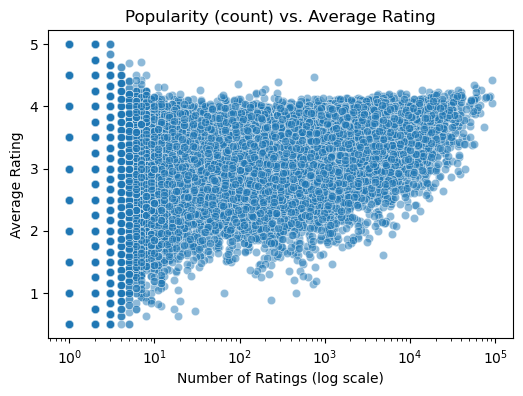

In [7]:
movie_stats = ratings_clean.groupby('movieId').agg(
    avg_rating=('rating','mean'),
    count=('rating','count')
).reset_index()

plt.figure(figsize=(6,4))
sns.scatterplot(data=movie_stats, x='count', y='avg_rating', alpha=0.5)
plt.xscale("log")
plt.title("Popularity (count) vs. Average Rating")
plt.xlabel("Number of Ratings (log scale)")
plt.ylabel("Average Rating")
plt.savefig(f"{results_folder}\\popularity_vs_rating.png", dpi=150)
plt.show()


“The relationship between popularity and average rating is highly skewed. Movies with very few ratings display extreme average scores (either very high or very low), while movies with thousands of ratings stabilize around average values (≈3–4.5). This highlights the need for weighted popularity baselines such as IMDb’s WR formula, since raw averages can be misleading for low-rated-count movies.”

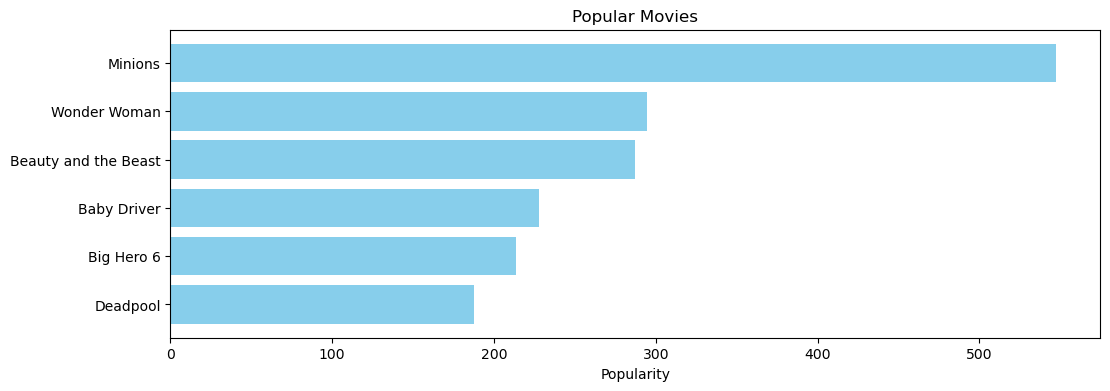

In [8]:
pop= movies_clean.sort_values('popularity', ascending=False)
plt.figure(figsize=(12,4))

plt.barh(pop['original_title'].head(6),pop['popularity'].head(6), align='center',
        color='skyblue')
plt.gca().invert_yaxis()
plt.xlabel("Popularity")
plt.title("Popular Movies")
plt.savefig(f"{results_folder}\\popular_movies.png", dpi=150)
plt.show()

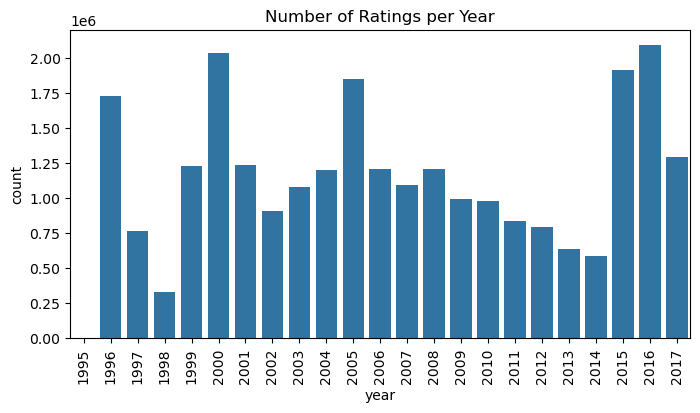

In [9]:
plt.figure(figsize=(8,4))
sns.countplot(x='year', data=ratings_clean, order=sorted(ratings_clean['year'].dropna().unique()))
plt.xticks(rotation=90)
plt.title("Number of Ratings per Year")
plt.savefig(f"{results_folder}\\ratings_per_year.png", dpi=150)
plt.show()

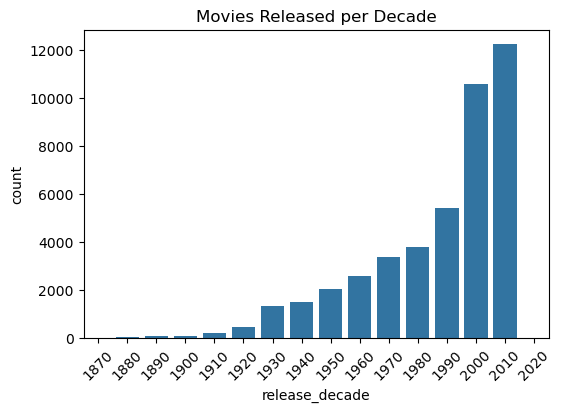

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(x='release_decade', data=movies_clean, order=sorted(movies_clean['release_decade'].unique()))
plt.xticks(rotation=45)
plt.title("Movies Released per Decade")
plt.savefig(f"{results_folder}\\movies_per_decade.png", dpi=150)
plt.show()

In [ ]:
def ensure_list(x):
    if isinstance(x, list):
        return x
    if pd.isna(x):
        return []
    try:
        return ast.literal_eval(x) if isinstance(x, str) else []
    except:
        return []

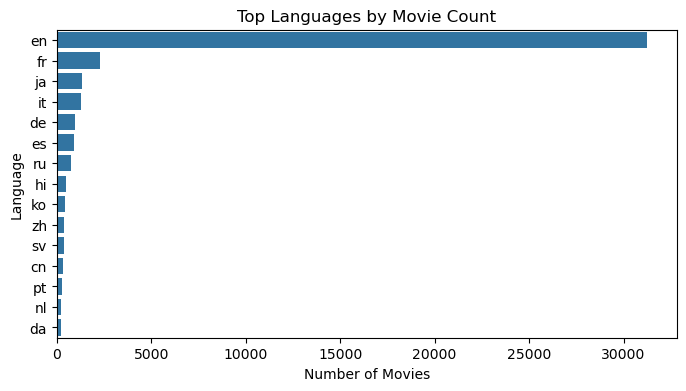

In [18]:
lang_counts = movies_clean['original_language'].value_counts().head(15)

plt.figure(figsize=(8,4))
sns.barplot(x=lang_counts.values, y=lang_counts.index)
plt.title("Top Languages by Movie Count")
plt.xlabel("Number of Movies")
plt.ylabel("Language")
plt.savefig(f"{results_folder}\\top_languages.png", dpi=150)
plt.show()


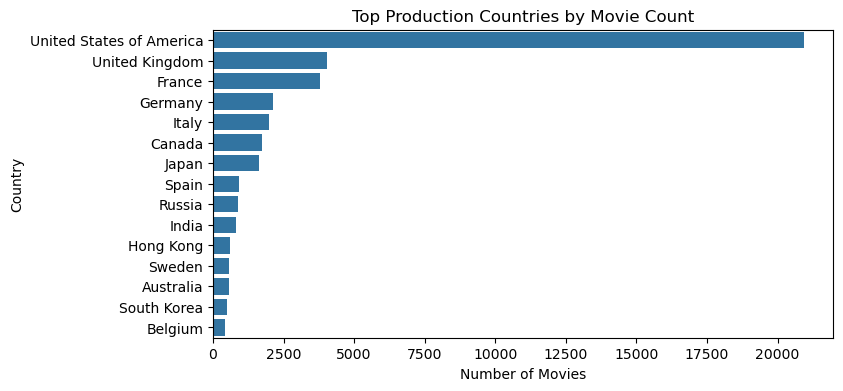

In [19]:
movies_clean['production_countries'] = movies_clean['production_countries'].apply(ensure_list)

all_countries = movies_clean['production_countries'].explode()

country_counts = all_countries.value_counts().head(15)

plt.figure(figsize=(8,4))
sns.barplot(x=country_counts.values, y=country_counts.index)
plt.title("Top Production Countries by Movie Count")
plt.xlabel("Number of Movies")
plt.ylabel("Country")
plt.savefig(f"{results_folder}\\top_countries.png", dpi=150)
plt.show()


“The dataset is dominated by English-language films (≈72%), with French (≈4%) and Spanish (≈3%) as the next most common languages. Similarly, the United States accounts for ≈40% of production countries, followed by the UK and France. This introduces potential bias in recommendations for non-English users."

In [20]:
# sparsity of the data
n_users = ratings_clean['userId'].nunique()
n_movies = ratings_clean['movieId'].nunique()
n_ratings = len(ratings_clean)

# Sparsity = 1 - Density
sparsity = 1 - (n_ratings / (n_users * n_movies))

print(f"Number of users: {n_users}")
print(f"Number of movies: {n_movies}")
print(f"Number of ratings: {n_ratings}")
print(f"Sparsity: {sparsity:.4f} ({sparsity*100:.2f}%)")


Number of users: 270896
Number of movies: 45115
Number of ratings: 26024289
Sparsity: 0.9979 (99.79%)


“The user–item interaction matrix is extremely sparse (≈99.8% empty). This is a common challenge, as most users interact with only a tiny fraction of the catalog."